# Ethiopia Climate EDA
## African Climate Trend Analysis — 10 Academy x Kifiya
### Task 2: Data Profiling, Cleaning & Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# Load the dataset
df = pd.read_csv('../data/ethiopia.csv')

# Add country column
df['Country'] = 'Ethiopia'

# Preview
print("Shape:", df.shape)
df.head()

Shape: (4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


## 1. Data Loading & Date Parsing
Convert YEAR and DOY columns into a proper datetime column.

In [4]:
# Convert YEAR + DOY into a proper date
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract Month
df['Month'] = df['Date'].dt.month

print("✅ Date column created")
print("Date range:", df['Date'].min(), "to", df['Date'].max())
df[['YEAR', 'DOY', 'Date', 'Month']].head()

✅ Date column created
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


## 2. Summary Statistics & Missing Value Report
NASA uses -999 as a sentinel value for missing/out-of-range data. We replace all -999 with NaN before any analysis.

In [5]:
# Replace NASA sentinel value
df.replace(-999, np.nan, inplace=True)

# Check duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df.drop_duplicates(inplace=True)

# Summary statistics
df.describe()

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [6]:
# Missing value analysis
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print("=== Missing Value Report ===")
print(missing_report[missing_report['Missing Count'] > 0])

=== Missing Value Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


## 3. Outlier Detection & Cleaning
We compute Z-scores for key weather variables. Rows where |Z| > 3 are flagged as outliers.

In [7]:
# Columns to check for outliers
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[cols].dropna()))
outlier_flags = (z_scores > 3)

print("=== Outlier Count per Column ===")
for i, col in enumerate(cols):
    print(f"{col}: {outlier_flags[:, i].sum()} outliers")

=== Outlier Count per Column ===
T2M: 3 outliers
T2M_MAX: 0 outliers
T2M_MIN: 18 outliers
PRECTOTCORR: 95 outliers
RH2M: 13 outliers
WS2M: 3 outliers
WS2M_MAX: 5 outliers


In [10]:
# Forward fill weather variables
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
                'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

df[weather_cols] = df[weather_cols].ffill()

# Drop rows where more than 30% of values are still missing
threshold = len(df.columns) * 0.3
df.dropna(thresh=int(threshold), inplace=True)

# Export cleaned data
df.to_csv('../data/ethiopia_clean.csv', index=False)
print(f"✅ Cleaned data exported. Shape: {df.shape}")

✅ Cleaned data exported. Shape: (4108, 15)


## 4. Time Series Analysis
### Monthly Average Temperature (2015–2026)

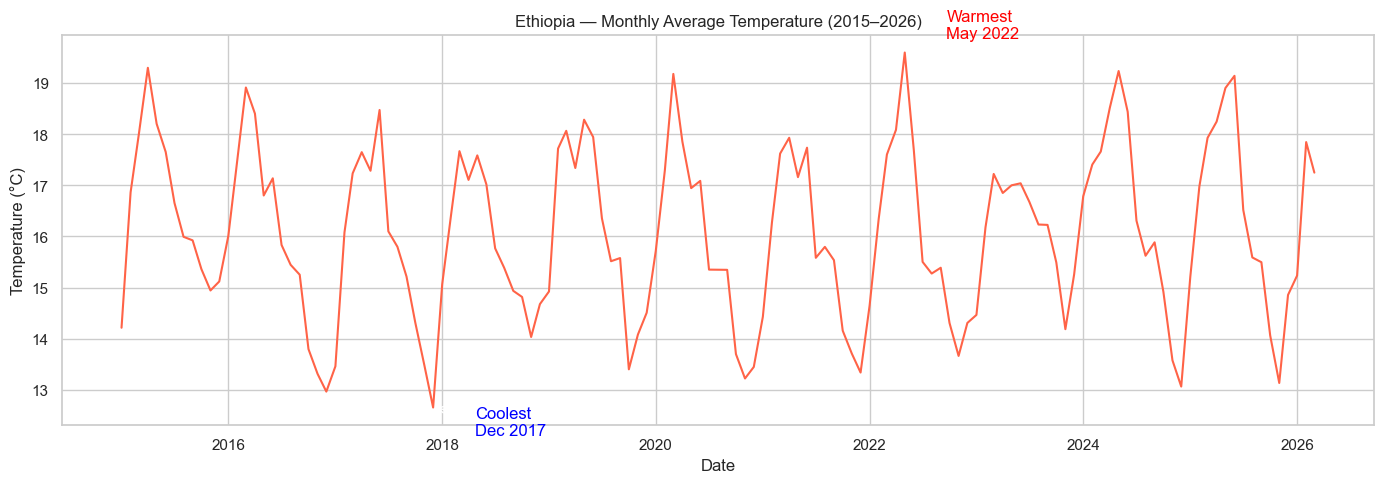

✅ Temperature time series plotted


In [11]:
# Monthly average temperature
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()
monthly_temp.index = monthly_temp.index.to_timestamp()

# Find warmest and coolest months
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp.index, monthly_temp.values, color='tomato', linewidth=1.5)
plt.annotate(f'Warmest\n{warmest.strftime("%b %Y")}',
             xy=(warmest, monthly_temp[warmest]),
             xytext=(30, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->'), color='red')
plt.annotate(f'Coolest\n{coolest.strftime("%b %Y")}',
             xy=(coolest, monthly_temp[coolest]),
             xytext=(30, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->'), color='blue')
plt.title('Ethiopia — Monthly Average Temperature (2015–2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_temp_timeseries.png', dpi=150)
plt.show()
print("✅ Temperature time series plotted")

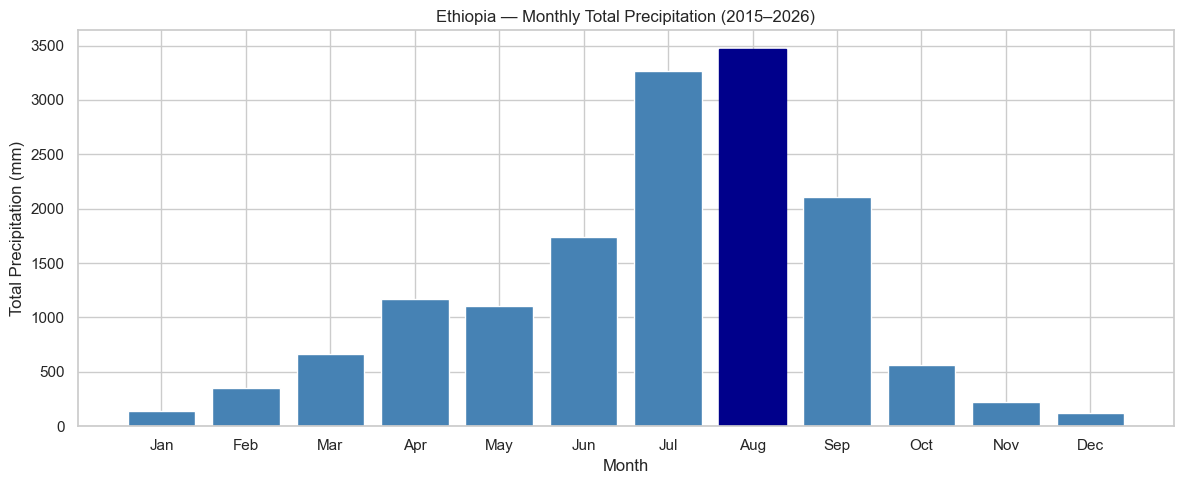

✅ Peak rainy month: Aug


In [12]:
# Monthly total precipitation
monthly_precip = df.groupby(df['Date'].dt.month)['PRECTOTCORR'].sum()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
bars = plt.bar(month_names, monthly_precip.values, color='steelblue')
# Highlight peak month
peak_month = monthly_precip.idxmax() - 1
bars[peak_month].set_color('darkblue')
plt.title('Ethiopia — Monthly Total Precipitation (2015–2026)')
plt.xlabel('Month')
plt.ylabel('Total Precipitation (mm)')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_precip_bar.png', dpi=150)
plt.show()
print(f"✅ Peak rainy month: {month_names[peak_month]}")

## 5. Correlation & Relationship Analysis

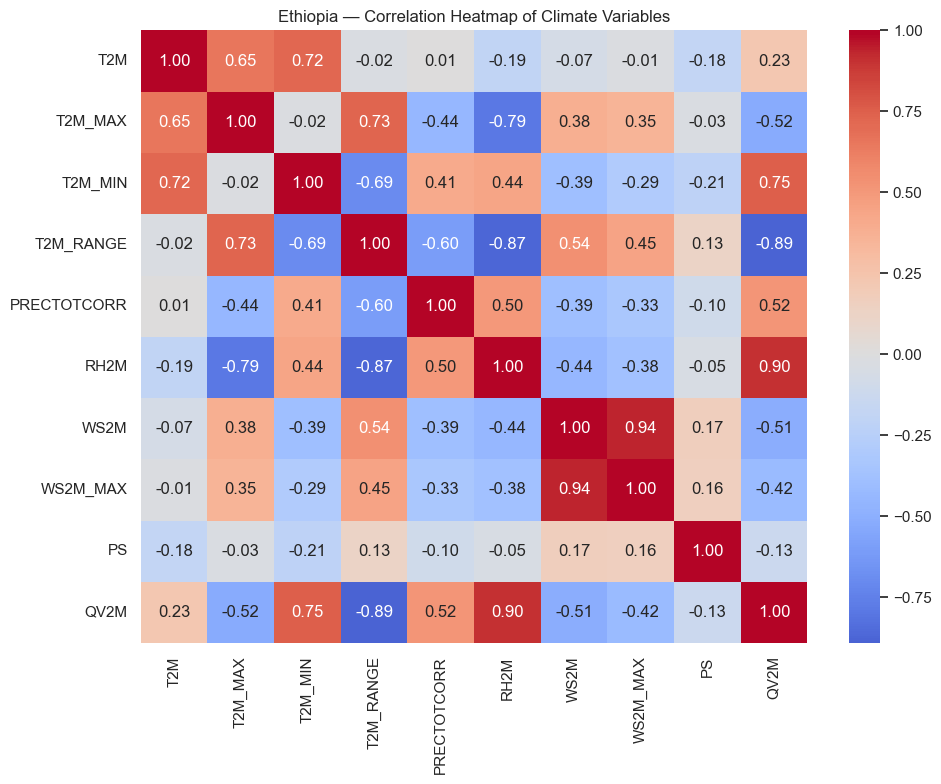

In [13]:
plt.figure(figsize=(10, 8))
corr = df[weather_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Ethiopia — Correlation Heatmap of Climate Variables')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_correlation_heatmap.png', dpi=150)
plt.show()

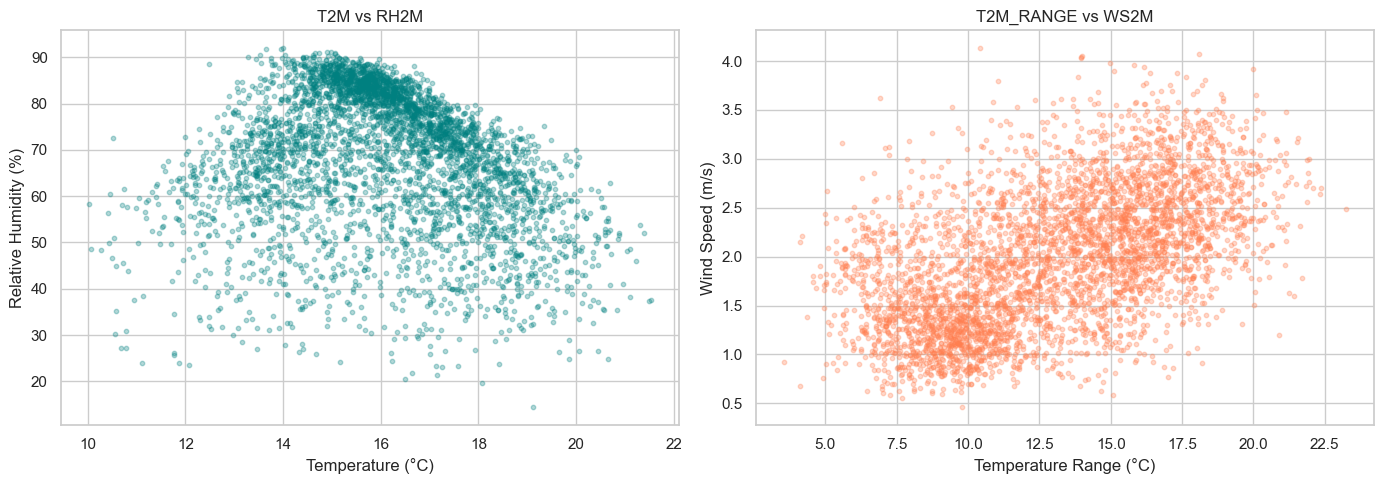

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal', s=10)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('T2M vs RH2M')

# T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral', s=10)
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('T2M_RANGE vs WS2M')

plt.tight_layout()
plt.savefig('../notebooks/ethiopia_scatter_plots.png', dpi=150)
plt.show()

## 6. Distribution Analysis

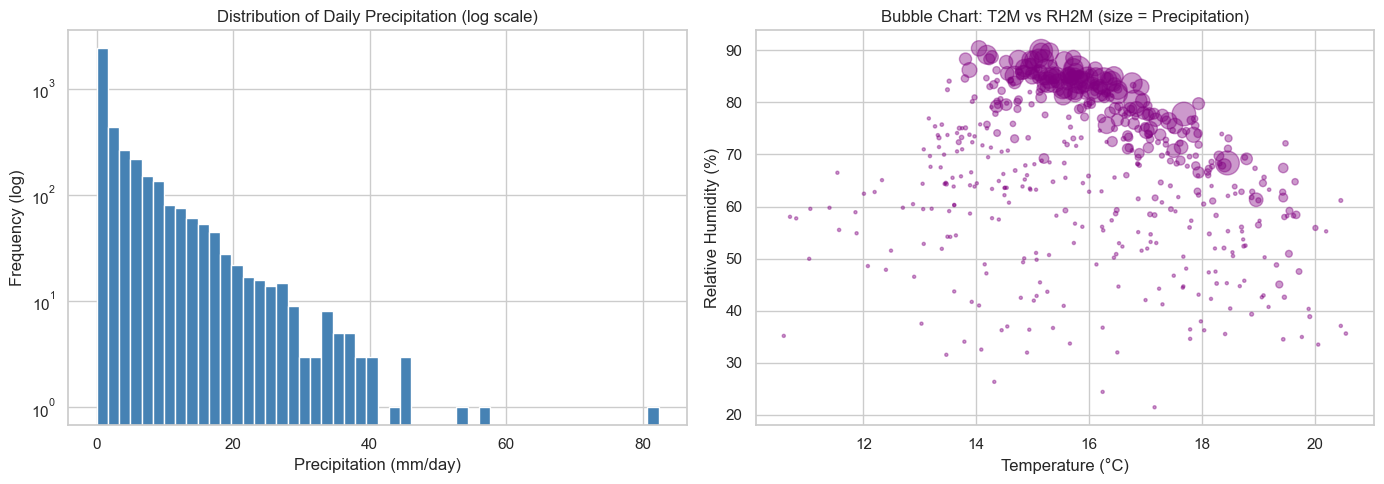

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of precipitation (log scale)
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Distribution of Daily Precipitation (log scale)')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].set_ylabel('Frequency (log)')

# Bubble chart
sample = df.sample(500, random_state=42)
axes[1].scatter(sample['T2M'], sample['RH2M'],
                s=sample['PRECTOTCORR'].fillna(0) * 10 + 5,
                alpha=0.4, color='purple')
axes[1].set_title('Bubble Chart: T2M vs RH2M (size = Precipitation)')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Relative Humidity (%)')

plt.tight_layout()
plt.savefig('../notebooks/ethiopia_distributions.png', dpi=150)
plt.show()

In [21]:
import importlib.util
import sys

spec = importlib.util.spec_from_file_location(
    "eda_template", 
    "scripts/eda_template.py"
)
eda = importlib.util.module_from_spec(spec)
spec.loader.exec_module(eda)

print("✅ Script loaded successfully!")

✅ Script loaded successfully!



  Running EDA for Kenya
Duplicates found: 0

Missing Values (%):
Series([], dtype: float64)

Outliers (|Z| > 3):
  T2M: 8
  T2M_MAX: 3
  T2M_MIN: 9
  PRECTOTCORR: 92
  RH2M: 6
  WS2M: 0
  WS2M_MAX: 6

✅ Cleaned data saved: data/kenya_clean.csv
   Shape: (4108, 15)


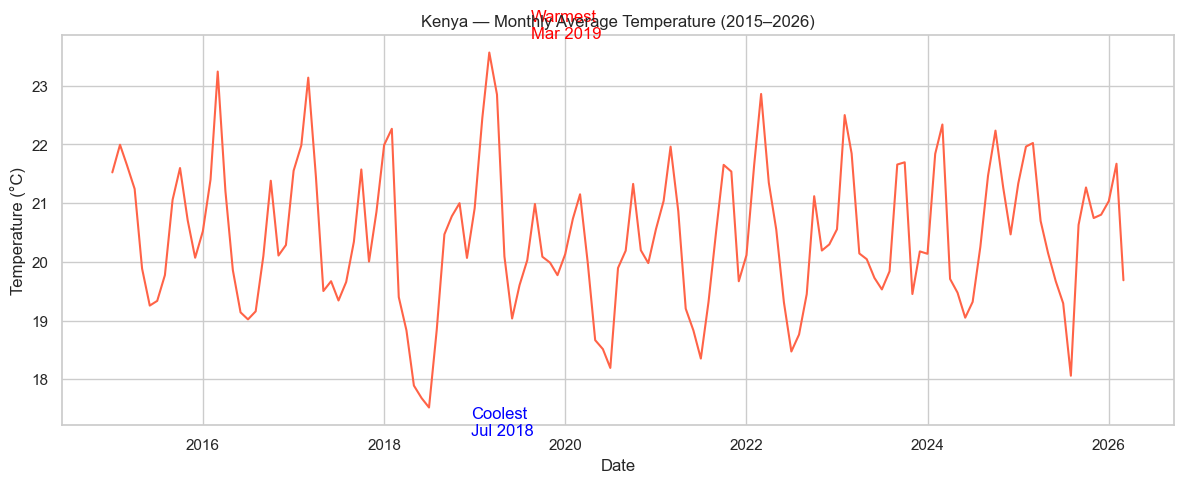

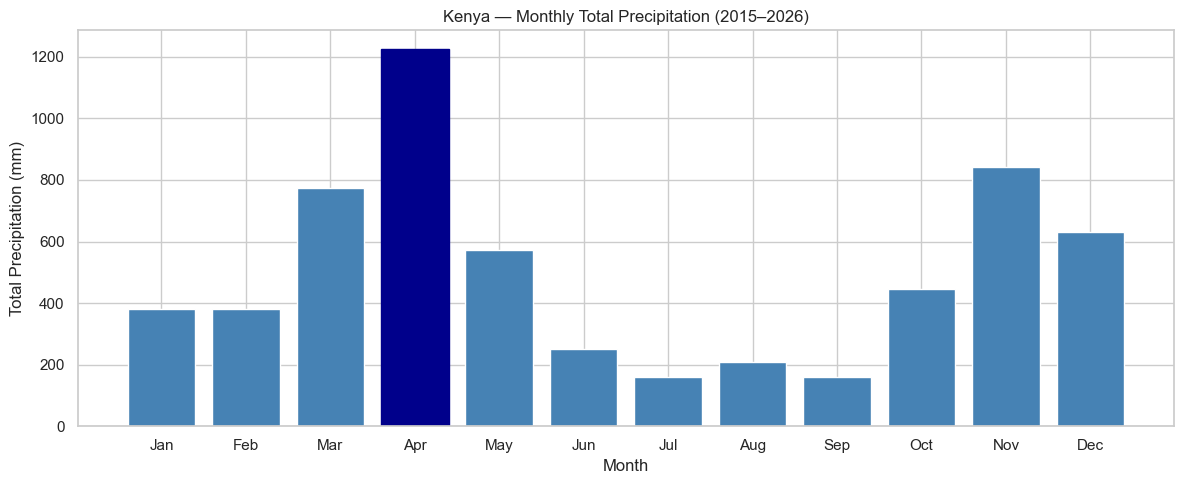

   Peak rainy month: Apr


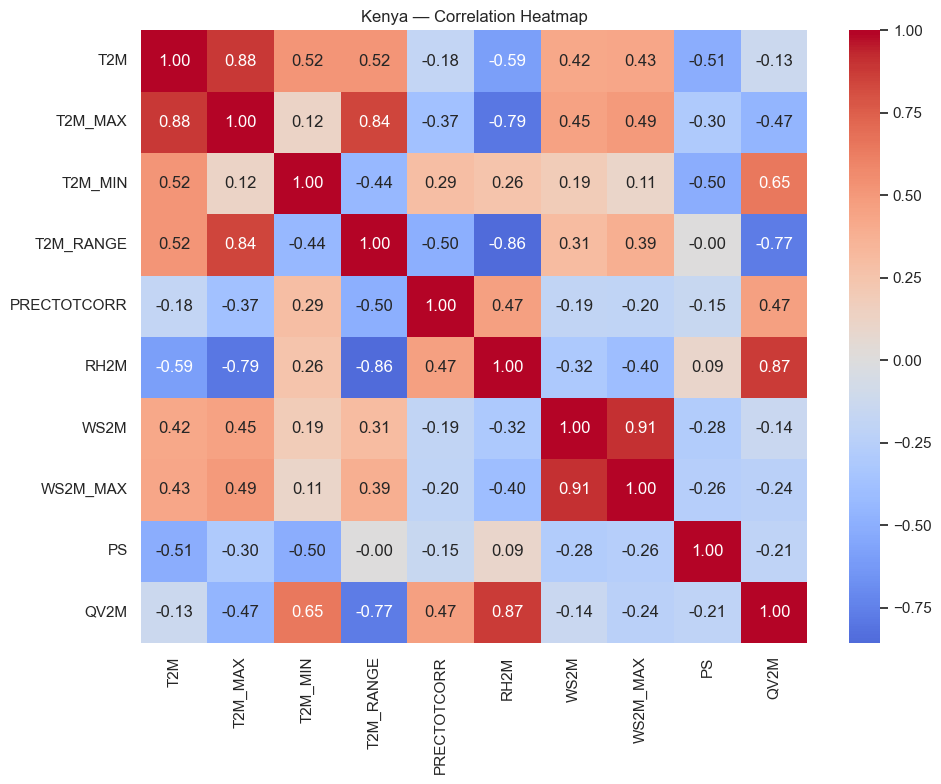

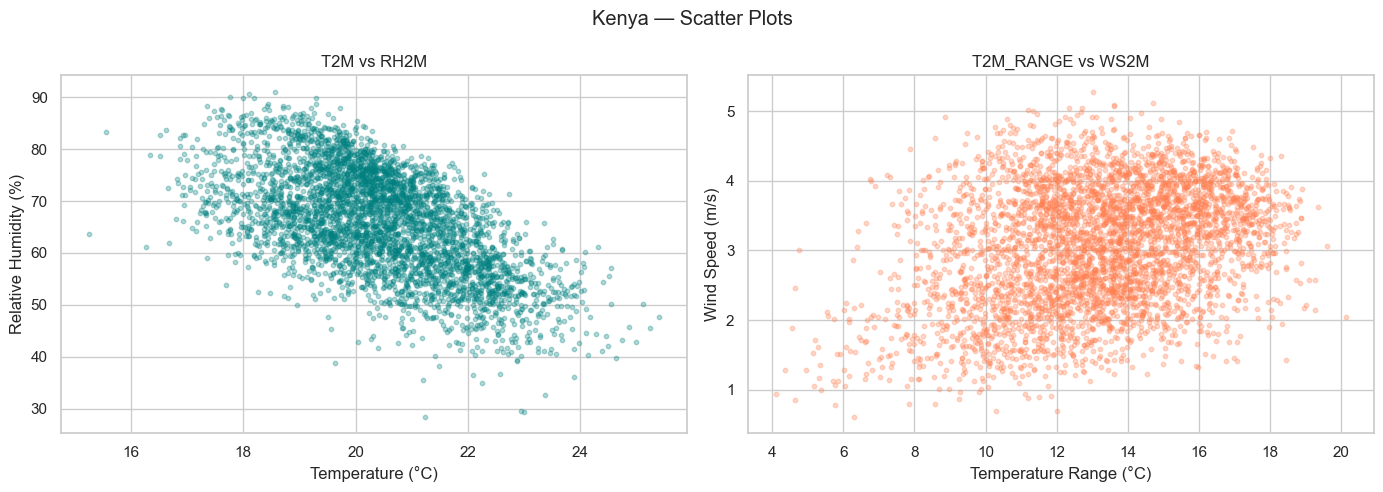

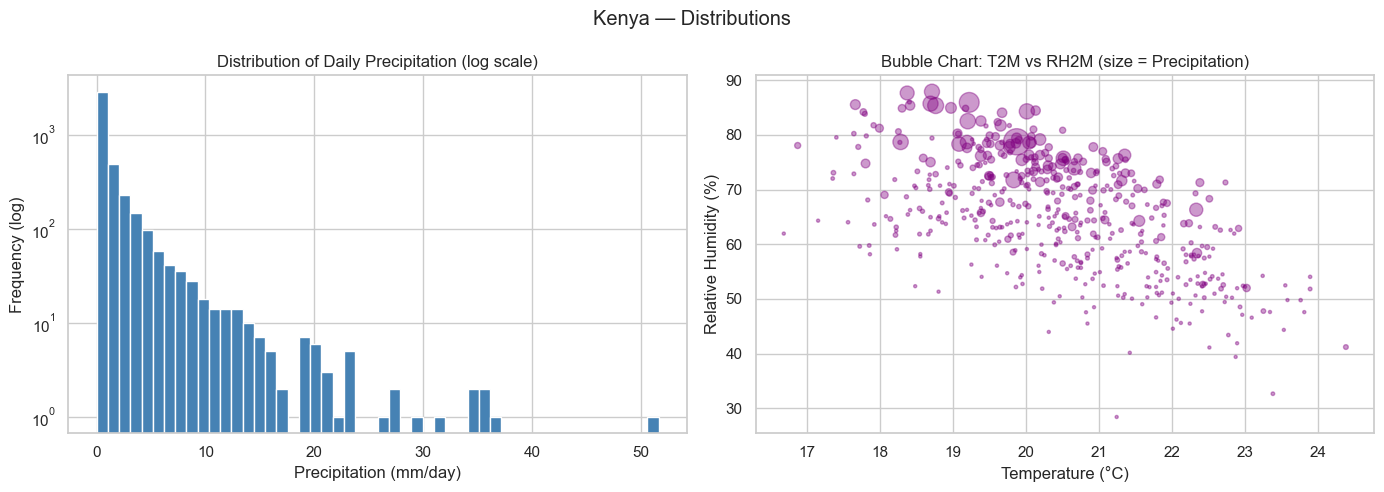


✅ Kenya EDA complete! All plots saved.

  Running EDA for Sudan
Duplicates found: 0

Missing Values (%):
Series([], dtype: float64)

Outliers (|Z| > 3):
  T2M: 3
  T2M_MAX: 6
  T2M_MIN: 1
  PRECTOTCORR: 71
  RH2M: 3
  WS2M: 4
  WS2M_MAX: 3

✅ Cleaned data saved: data/sudan_clean.csv
   Shape: (4108, 15)


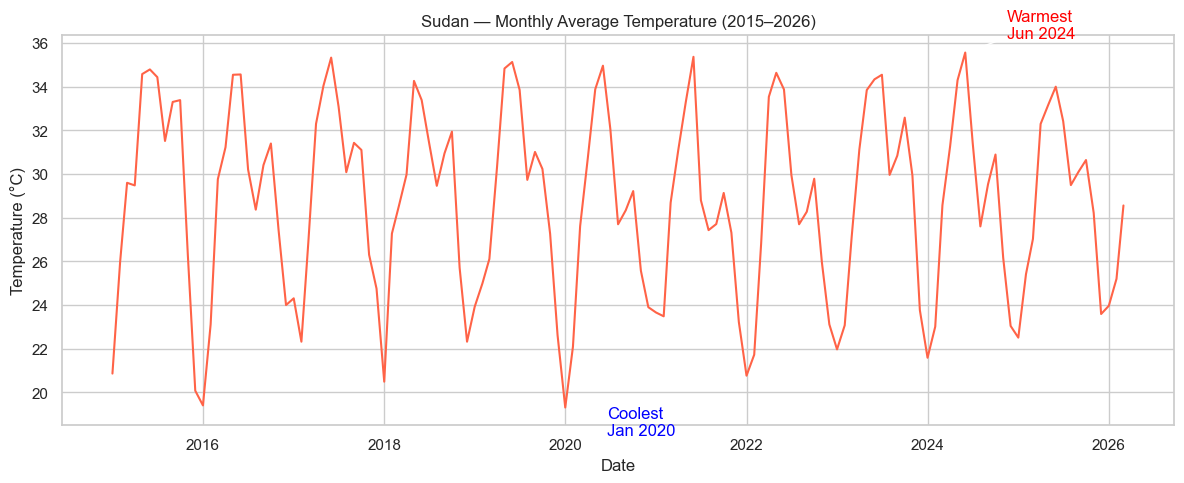

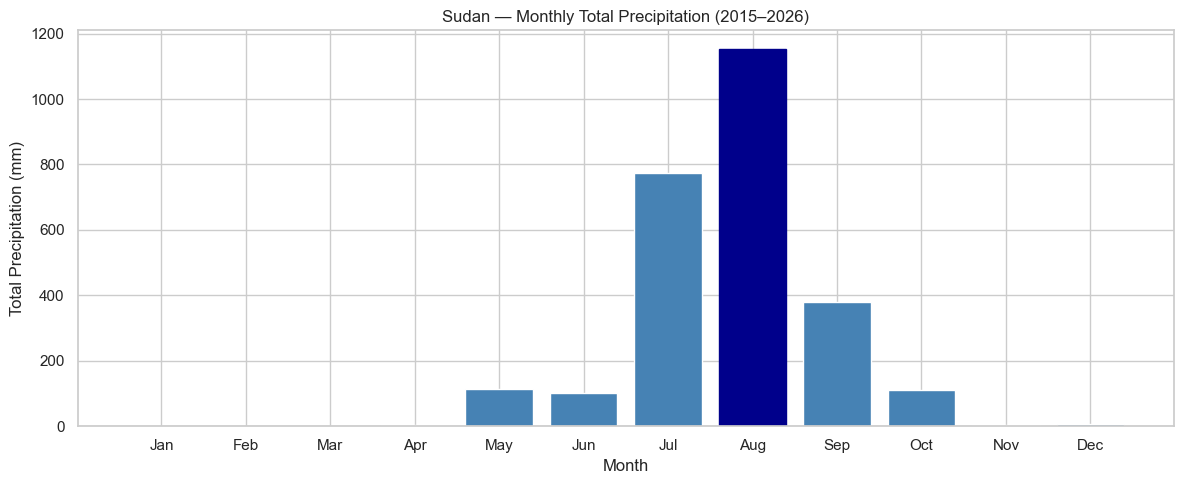

   Peak rainy month: Aug


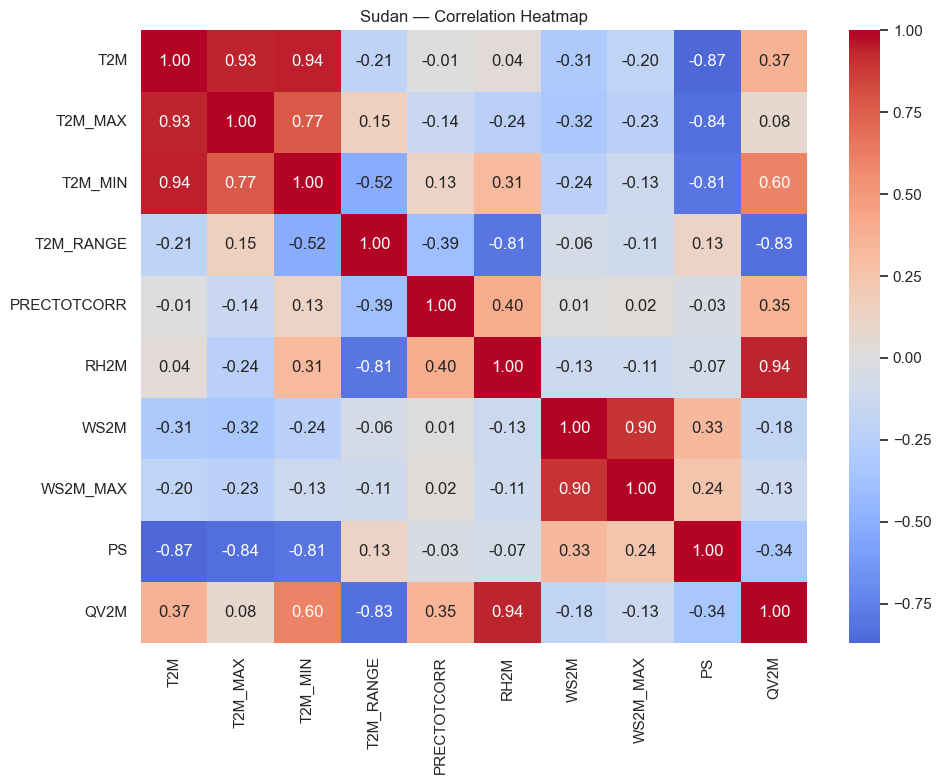

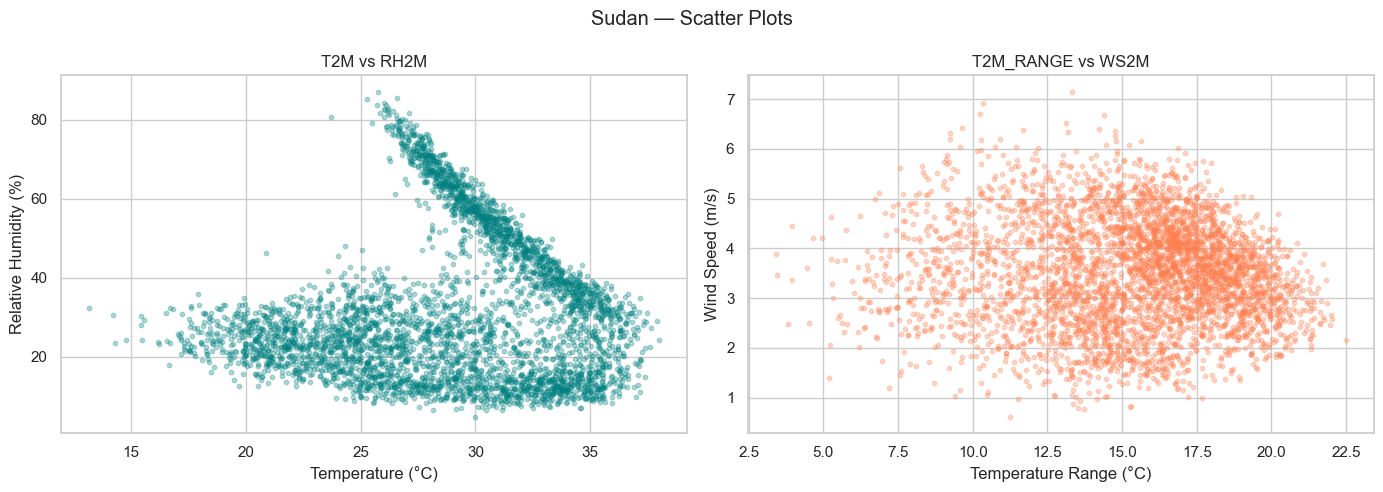

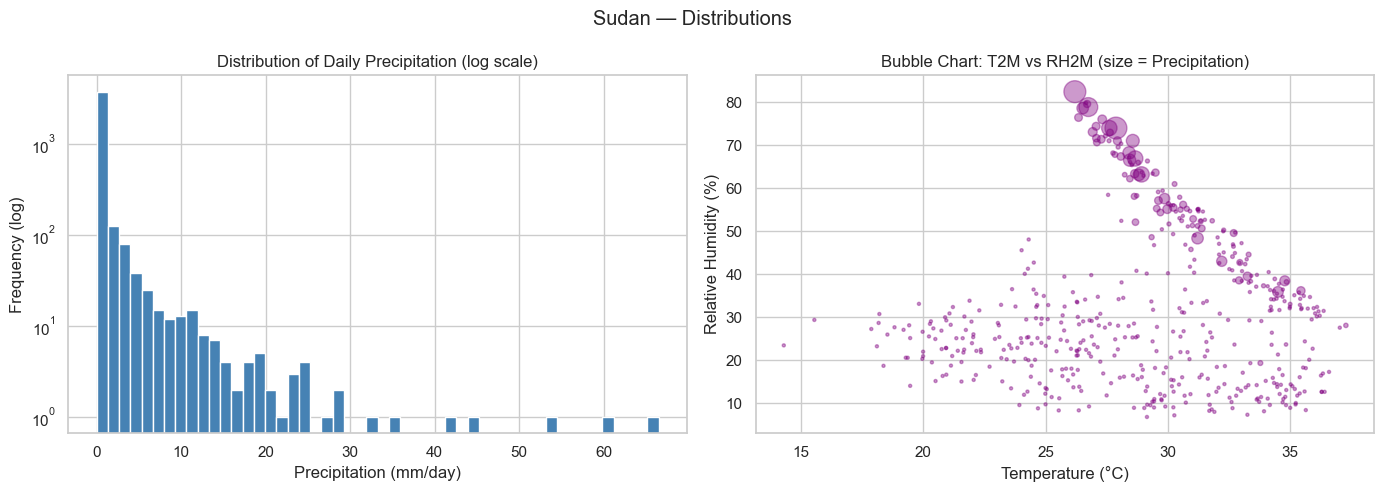


✅ Sudan EDA complete! All plots saved.

  Running EDA for Tanzania
Duplicates found: 0

Missing Values (%):
Series([], dtype: float64)

Outliers (|Z| > 3):
  T2M: 1
  T2M_MAX: 2
  T2M_MIN: 4
  PRECTOTCORR: 81
  RH2M: 2
  WS2M: 8
  WS2M_MAX: 4

✅ Cleaned data saved: data/tanzania_clean.csv
   Shape: (4108, 15)


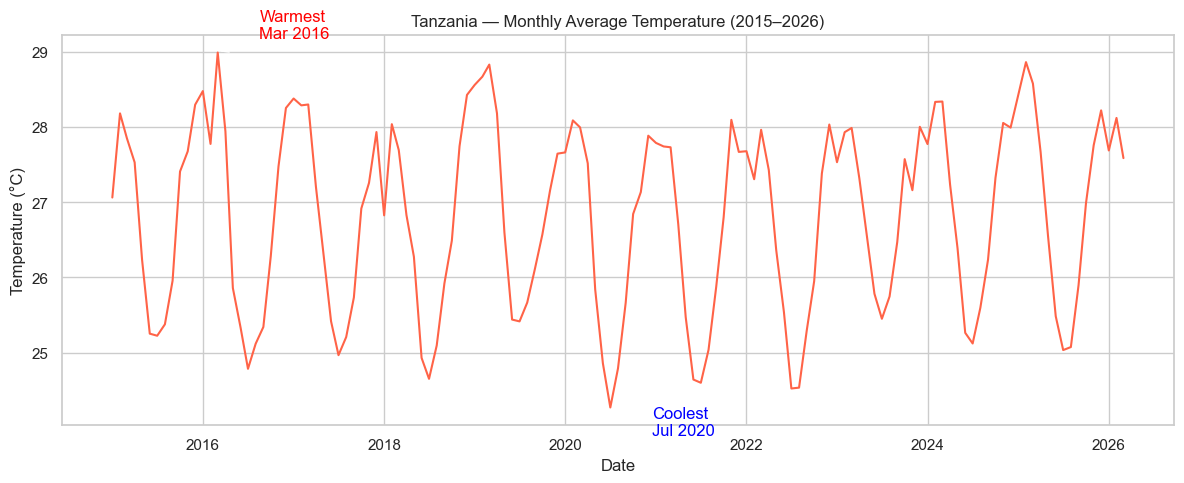

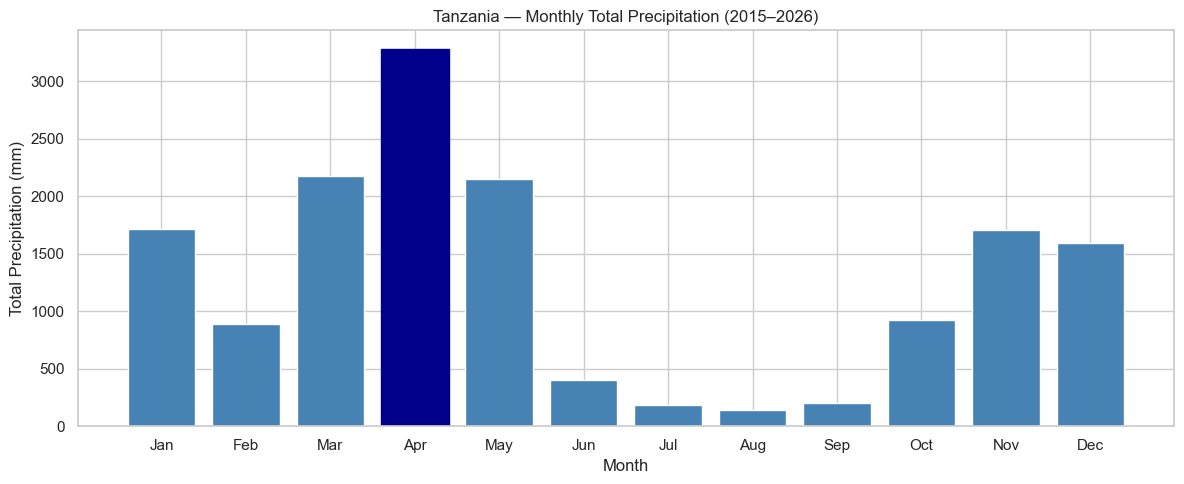

   Peak rainy month: Apr


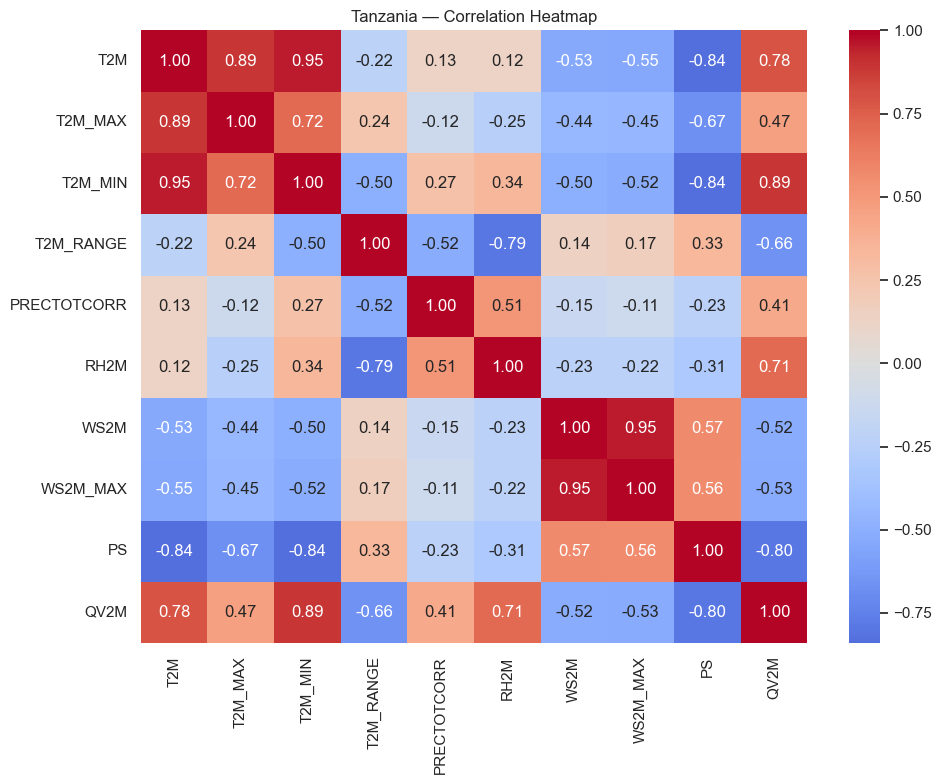

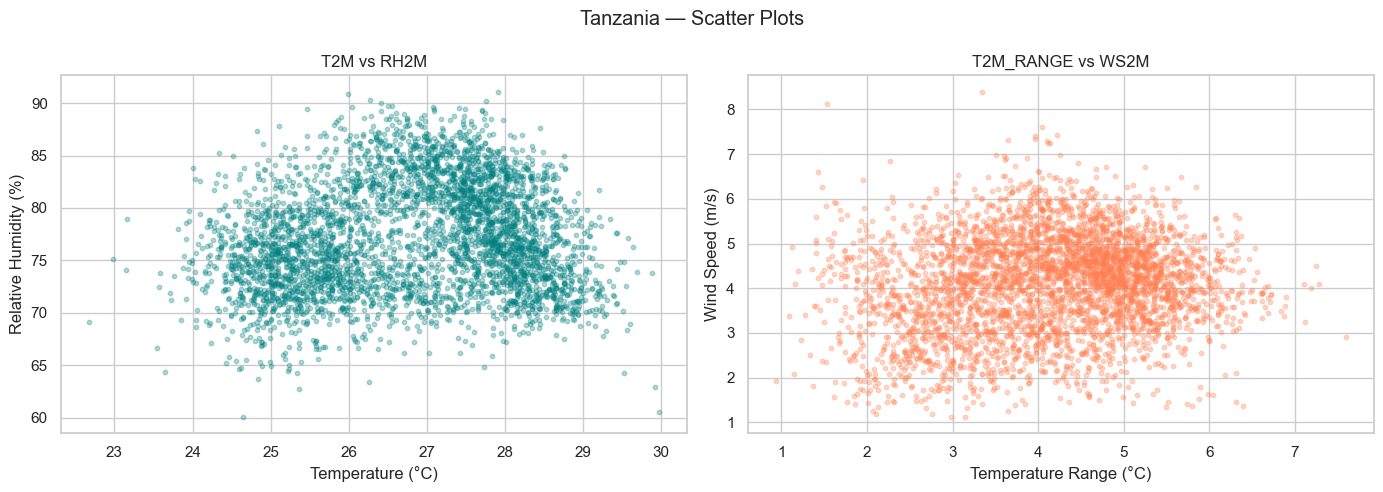

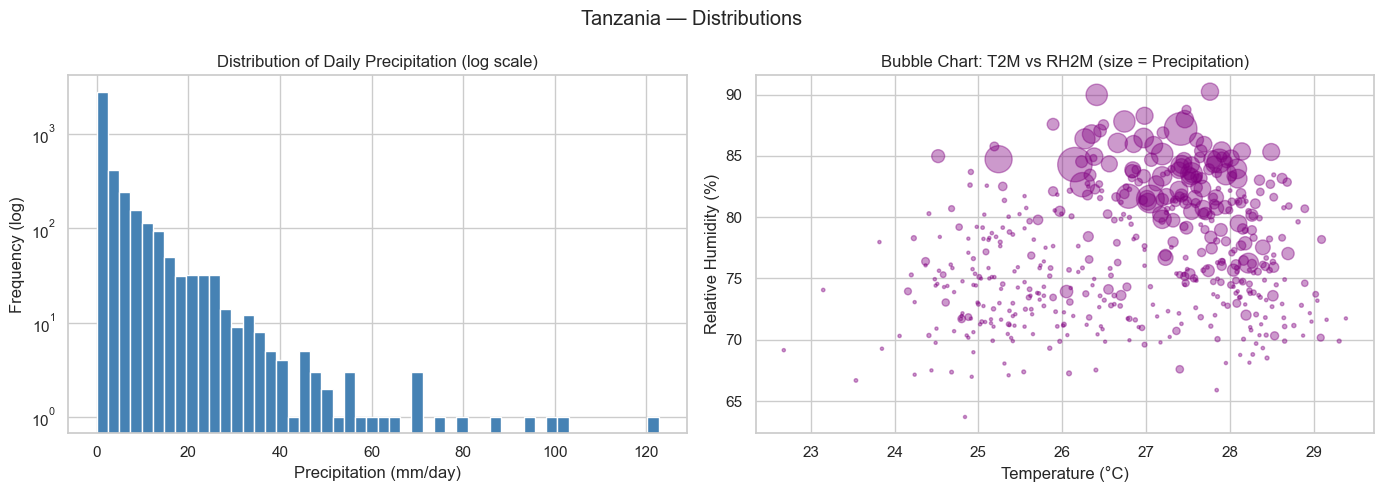


✅ Tanzania EDA complete! All plots saved.

  Running EDA for Nigeria
Duplicates found: 0

Missing Values (%):
Series([], dtype: float64)

Outliers (|Z| > 3):
  T2M: 10
  T2M_MAX: 1
  T2M_MIN: 68
  PRECTOTCORR: 75
  RH2M: 128
  WS2M: 5
  WS2M_MAX: 10

✅ Cleaned data saved: data/nigeria_clean.csv
   Shape: (4108, 15)


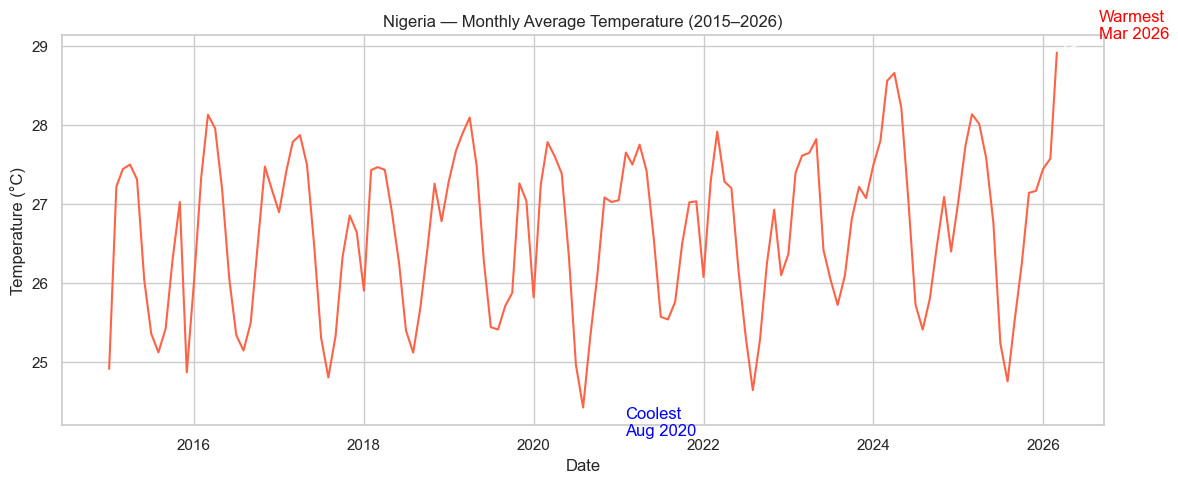

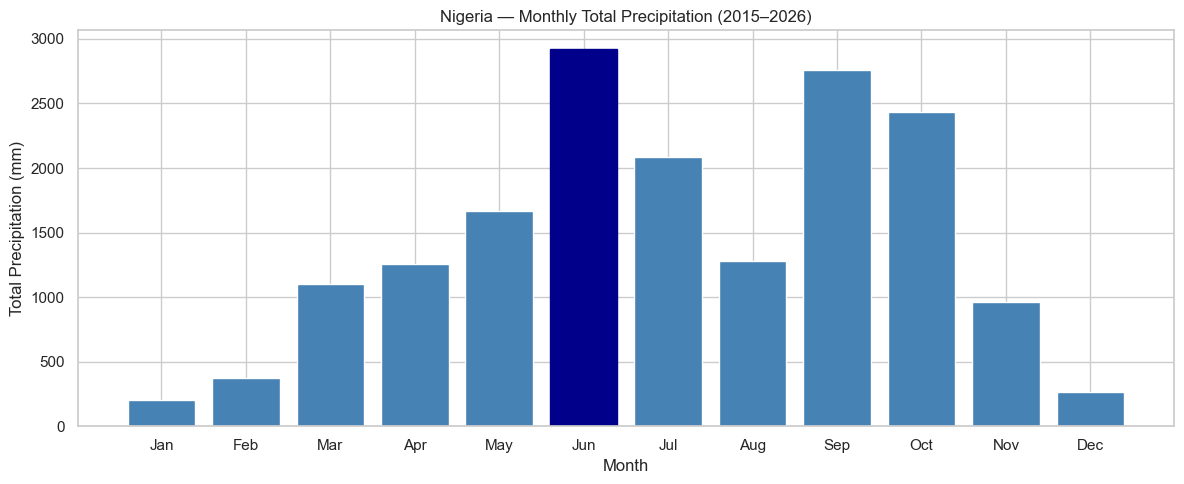

   Peak rainy month: Jun


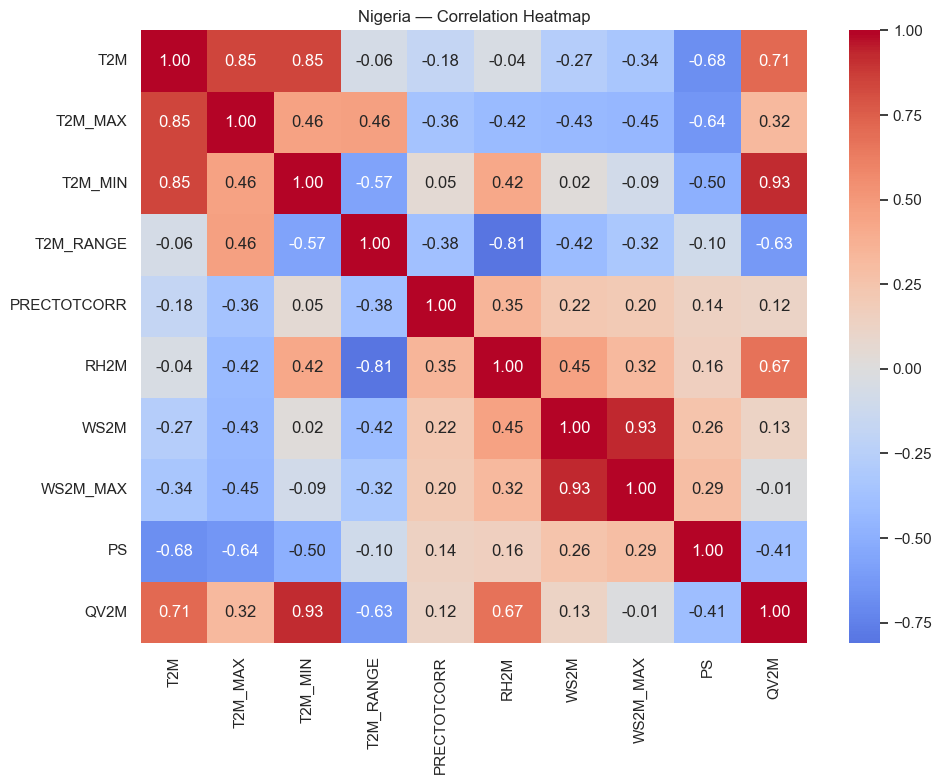

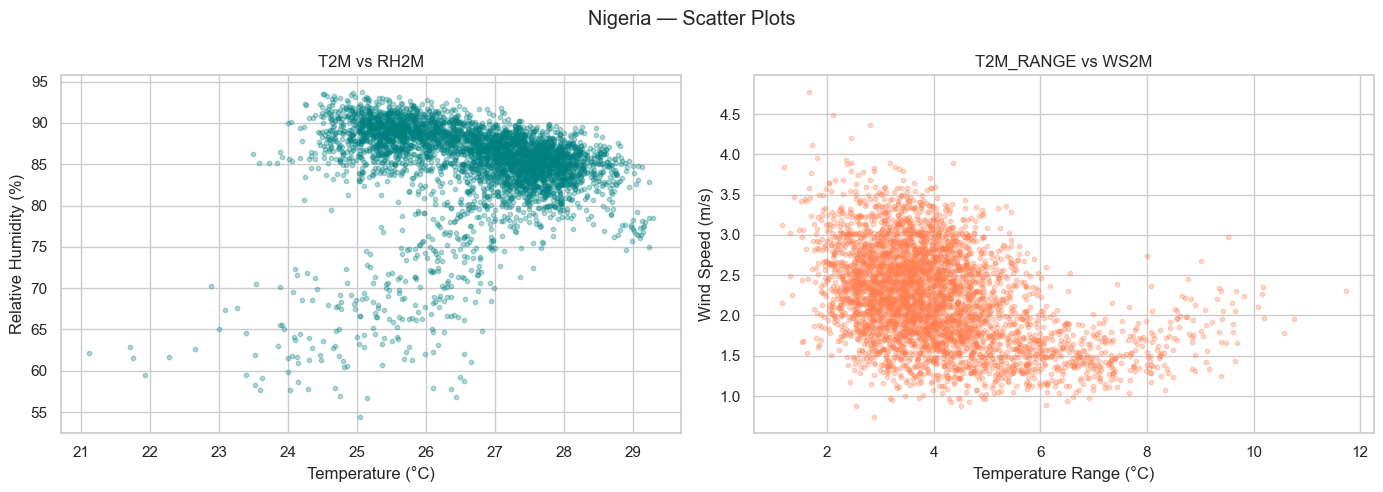

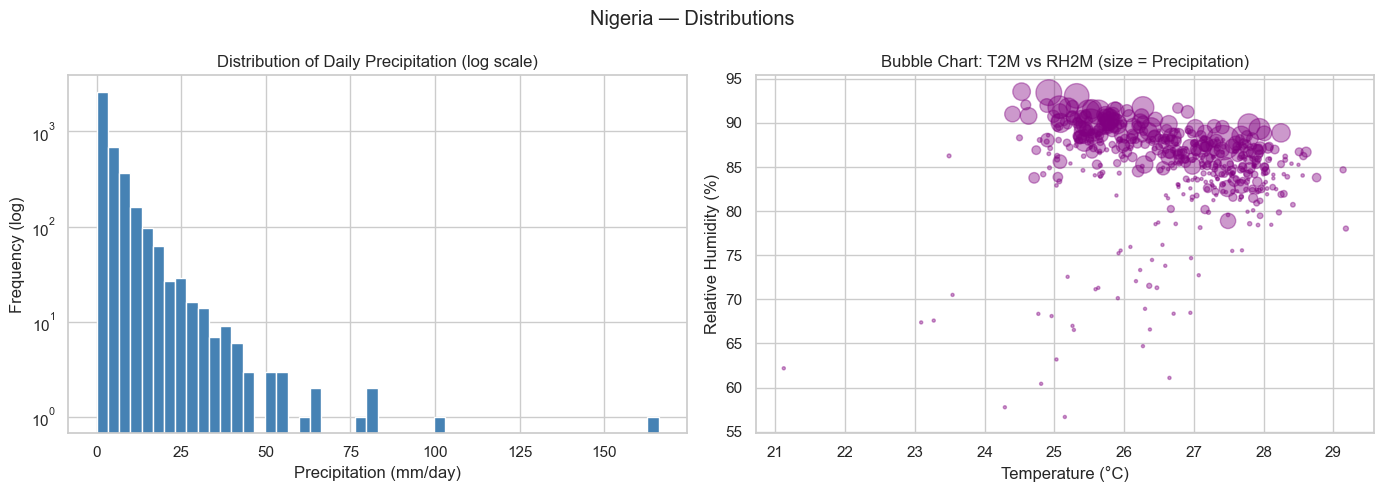


✅ Nigeria EDA complete! All plots saved.


In [22]:
for country in ['Kenya', 'Sudan', 'Tanzania', 'Nigeria']:
    eda.run_eda(country)